In [1]:
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

# Check MMDetection installation
import mmdet
print(mmdet.__version__)

# Check mmcv installation
from mmcv.ops import get_compiling_cuda_version, get_compiler_version
print(get_compiling_cuda_version())
print(get_compiler_version())

1.10.0 True
2.18.0
10.2
GCC 7.3


In [2]:
import mmcv
import matplotlib.pyplot as plt

In [3]:
import mmcv
from mmcv import Config
cfg = Config.fromfile('/home/erik/Riksarkivet/Projects/fastighet/models/configs/cascade_rcnn2.py')

In [4]:
from mmdet.apis import set_random_seed

# Modify dataset type and path
#cfg.dataset_type = 'KittiTinyDataset'

# modify num classes of the model in box head
#cfg.model.roi_head.bbox_head.num_classes = 1
# We can still use the pre-trained Mask RCNN model though we do not need to
# use the mask branch
cfg.load_from = '/home/erik/Riksarkivet/Projects/fastighet/models/checkpoints/cascade_rcnn_r101_caffe_fpn_1x_coco_bbox_mAP-0.423_20200504_175649-cab8dbd5.pth'

# Set up working dir to save files and logs.
cfg.work_dir = '/home/erik/Riksarkivet/Projects/fastighet/models/cascade_rcnn_1'

# The original learning rate (LR) is set for 8-GPU training.
# We divide it by 8 since we only use one GPU.
cfg.optimizer.lr = 0.02 / 8
cfg.lr_config.warmup = None
cfg.log_config.interval = 50

# Change the evaluation metric since we use customized dataset.
cfg.evaluation.metric = 'bbox'
# We can set the evaluation interval to reduce the evaluation times
cfg.evaluation.interval = 1
# We can set the checkpoint saving interval to reduce the storage cost
cfg.checkpoint_config.interval = 1

# Set seed thus the results are more reproducible
cfg.seed = 0
set_random_seed(0, deterministic=False)
cfg.gpu_ids = range(1)


In [5]:
from mmdet.datasets import build_dataset
from mmdet.models import build_detector
from mmdet.apis import train_detector
import os


# Build dataset
datasets = [build_dataset(cfg.data.train)]

# Build the detector
model = build_detector(
    cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
# Add an attribute for visualization convenience
model.CLASSES = datasets[0].CLASSES

# Create work_dir
mmcv.mkdir_or_exist(os.path.abspath(cfg.work_dir))
train_detector(model, datasets, cfg, distributed=False, validate=True)

 memory: 2589, loss_rpn_cls: 0.0008, loss_rpn_bbox: 0.0019, s0.loss_cls: 0.0068, s0.acc: 99.7363, s0.loss_bbox: 0.0052, s1.loss_cls: 0.0040, s1.acc: 99.7031, s1.loss_bbox: 0.0120, s2.loss_cls: 0.0029, s2.acc: 99.5234, s2.loss_bbox: 0.0148, loss: 0.0483
2021-12-08 12:54:14,697 - mmdet - INFO - Epoch [11][550/1397]	lr: 2.500e-04, eta: 0:09:00, time: 0.244, data_time: 0.003, memory: 2589, loss_rpn_cls: 0.0015, loss_rpn_bbox: 0.0013, s0.loss_cls: 0.0068, s0.acc: 99.7363, s0.loss_bbox: 0.0045, s1.loss_cls: 0.0030, s1.acc: 99.7598, s1.loss_bbox: 0.0117, s2.loss_cls: 0.0019, s2.acc: 99.7168, s2.loss_bbox: 0.0150, loss: 0.0457
2021-12-08 12:54:26,956 - mmdet - INFO - Epoch [11][600/1397]	lr: 2.500e-04, eta: 0:08:48, time: 0.245, data_time: 0.004, memory: 2589, loss_rpn_cls: 0.0007, loss_rpn_bbox: 0.0022, s0.loss_cls: 0.0074, s0.acc: 99.6797, s0.loss_bbox: 0.0056, s1.loss_cls: 0.0038, s1.acc: 99.6934, s1.loss_bbox: 0.0135, s2.loss_cls: 0.0025, s2.acc: 99.6309, s2.loss_bbox: 0.0166, loss: 0.0522

In [4]:
from mmdet.apis import inference_detector, init_detector, show_result_pyplot
checkpoint = '/home/erik/Riksarkivet/Projects/fastighet/models/cascade_rcnn_1/latest.pth'
model = init_detector(cfg, checkpoint, device='cuda:0')

Use load_from_local loader


/home/erik/anaconda3/envs/openmmlab/lib/python3.7/site-packages/mmdet/datasets/utils.py:69: UserWarning: "ImageToTensor" pipeline is replaced by "DefaultFormatBundle" for batch inference. It is recommended to manually replace it in the test data pipeline in your config file.
  'data pipeline in your config file.', UserWarning)


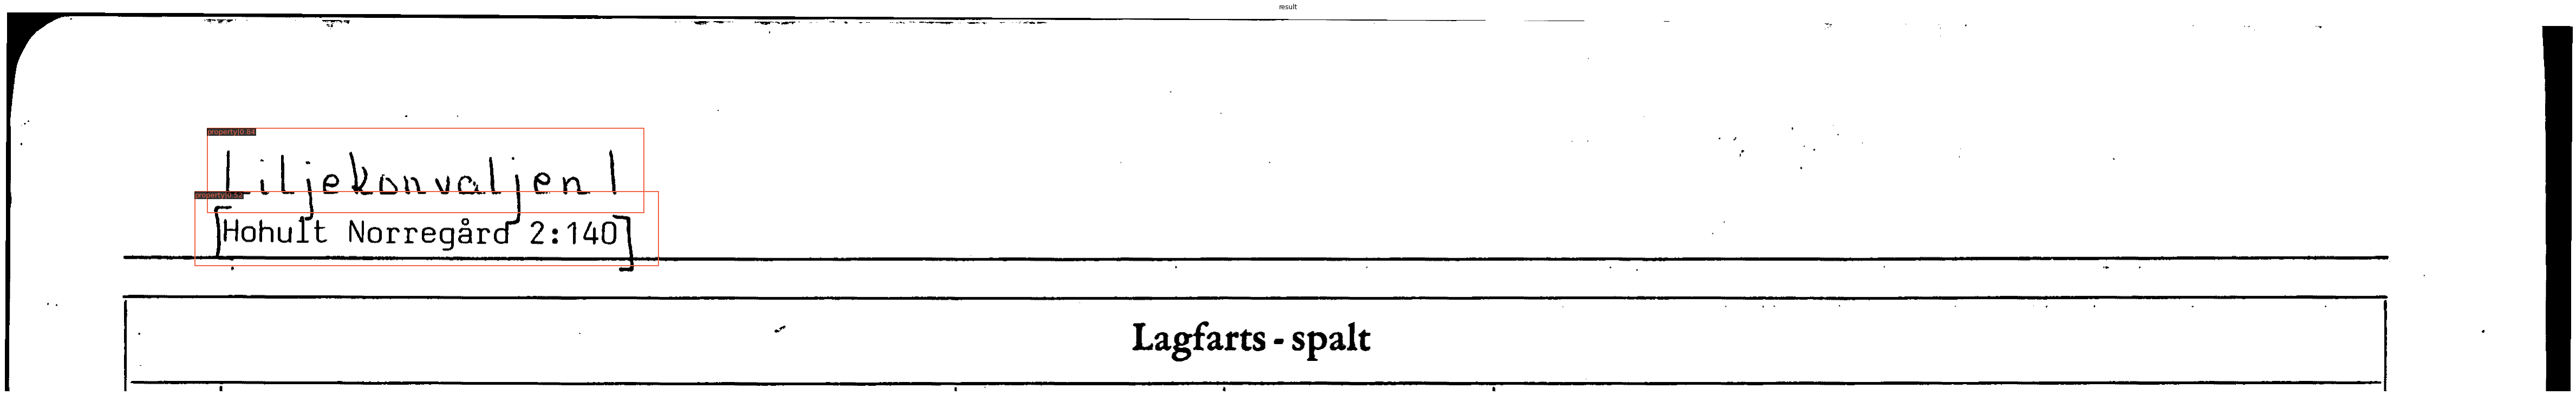

"out = Path(img).name\nout = out.split('-')[1]\nout_p = os.path.join('/content/drive/MyDrive/Riksarkivet/Fastighet/testmodel_mmdet/inference_on_eval_set', out)\nmodel.show_result(im, result, out_file=out_p)"

In [5]:
im = mmcv.imread('/home/erik/Riksarkivet/Projects/fastighet/data/Sidhuvuden700/10001439/10001439_00000006.tif')

#model.cfg = cfg
result = inference_detector(model, im)
show_result_pyplot(model, im, result, score_thr=0.3)
"""out = Path(img).name
out = out.split('-')[1]
out_p = os.path.join('/content/drive/MyDrive/Riksarkivet/Fastighet/testmodel_mmdet/inference_on_eval_set', out)
model.show_result(im, result, out_file=out_p)"""

In [11]:
print(len(result[0]))

2


In [20]:
%%time

from glob import glob
from pathlib import Path
import os
import mmcv

path_to_imgs = '/home/erik/Riksarkivet/Projects/fastighet/data/testbatch/10001001'
imgs = glob(os.path.join(path_to_imgs, '**'))
imgs.sort()

for i, img in enumerate(imgs):
  im = mmcv.imread(img)
  
  

  #model.cfg = cfg
  #result = inference_detector(model, im)
  #show_result_pyplot(model, im, result, score_thr=0.6)
  #out = Path(img).name
  #out_p = os.path.join('/home/erik/Riksarkivet/Projects/fastighet/data/testbatch/results', out)
  #model.show_result(im, result, out_file=out_p)
  #if i % 20 == 0:
    #print(i)

CPU times: user 2.93 s, sys: 280 ms, total: 3.21 s
Wall time: 2.2 s


In [10]:
for r in result:
    print(r)

[]
